In [7]:
"""
Experimental Fluid Mechanics: Centrifugal Blower Performance Analysis
Objective: Characterize the performance curves (Head and Power vs. Flow Rate) 
of a centrifugal blower at different frequencies (30Hz and 60Hz) and validate 
the results using Rateau's Similarity Laws.

Libraries used:
- CoolProp: For high-accuracy fluid properties (density, viscosity).
- uncertainties: For automatic error propagation of experimental measurements.
- pandas: For data structuring and management.
- matplotlib: For generating performance curves.
- tabulate: For professional data presentation.
"""

# Install necessary libraries (uncomment if running in Colab)
# !pip install CoolProp uncertainties tabulate

import matplotlib.pyplot as plt
import pandas as pd
from CoolProp.CoolProp import PropsSI
from math import pi, e
from uncertainties import ufloat
from tabulate import tabulate
from IPython.display import HTML, display

print("Libraries and environment setup complete.")

Libraries and environment setup complete.


In [8]:
# --- Standard Experimental Constants ---
# Nominal rotation and geometric parameters
rotation_ref = ufloat(3438, 0)                # RPM
pipe_diameter = ufloat(74e-3, 0.5e-3)         # m (D)
orifice_diameter = ufloat(47.80e-3, 0.02e-3)  # m (d)

# Environmental conditions
temp_k = ufloat(25.10 + 273.15, 0.5)          # Kelvin
p_amb = ufloat(92792.4, 67)                   # Pascals
g = ufloat(9.78, 0.01)                        # m/s²

# Fluid definition for CoolProp
fluid = 'air'
water = 'water'

# Convergence criteria for iterative Reynolds calculation
tol = 1e-2
max_iter = 500

# Reference Water Density (for manometer conversion)
rho_water = ufloat(PropsSI("D", "T", temp_k.nominal_value, "P", p_amb.nominal_value, water), 0)

# Blower baseline efficiency
eta_nominal = ufloat(0.328, 0)

print(f"Fluid properties initialized. Water density: {rho_water:.2f} kg/m³")

Fluid properties initialized. Water density: 997.02+/-0 kg/m³


In [9]:
# Creating DataFrames for 30Hz and 60Hz operations
# deltaH: Pressure head across the blower
# deltaQ: Pressure drop across the orifice plate

freq_30_df = pd.DataFrame({
    'deltaH (m)': [
        ufloat(54.5e-3, 0.5e-3), ufloat(58.5e-3, 0.5e-3),
        ufloat(66.5e-3, 0.5e-3), ufloat(70.0e-3, 0.5e-3),
        ufloat(75.0e-3, 0.5e-3)
    ],
    'deltaQ (m)': [
        ufloat(53.5e-3, 0.5e-3), ufloat(45.7e-3, 0.5e-3),
        ufloat(26.5e-3, 0.5e-3), ufloat(18.0e-3, 0.5e-3),
        ufloat(10.6e-3, 0.5e-3)
    ]
}, index=range(1, 6))

freq_60_df = pd.DataFrame({
    'deltaH (m)': [
        ufloat(213e-3, 0.5e-3), ufloat(224e-3, 0.5e-3),
        ufloat(266e-3, 0.5e-3), ufloat(284e-3, 0.5e-3),
        ufloat(299e-3, 0.5e-3)
    ],
    'deltaQ (m)': [
        ufloat(213e-3, 0.5e-3), ufloat(144e-3, 0.5e-3),
        ufloat(106e-3, 0.5e-3), ufloat(71e-3,  0.5e-3),
        ufloat(40e-3,  0.5e-3)
    ]
}, index=range(1, 6))

print("Experimental data loaded into DataFrames.")

Experimental data loaded into DataFrames.


In [10]:
def calculate_flow(H_man, Q_man):
    """Calculates real mass and volumetric flow using ISO 5167 orifice plate iteration."""
    area_orifice = pi * orifice_diameter**2 / 4
    rho_air = ufloat(PropsSI("D", "T", temp_k.nominal_value, "P", p_amb.nominal_value, fluid), 0)
    mu_air = ufloat(PropsSI("V", "T", temp_k.nominal_value, "P", p_amb.nominal_value, fluid), 0)
    beta = orifice_diameter / pipe_diameter
    delta_p = rho_water * g * Q_man

    # Iterative process for Reynolds number (Re) and Discharge Coefficient (C)
    reynolds = 100.0
    for i in range(1, max_iter + 1):
        A = ((1.9e4 * beta) / reynolds)**0.8
        M2 = (2 * 0.47) / (1 - beta)
        C = (0.5961 + 0.0261 * beta**2 - 0.216 * beta**8 + 0.000521 * ((1e6 * beta) / reynolds)**0.7
             + (0.0188 + 0.0063 * A) * beta**3.5 * (1e6 / reynolds)**0.3
             + ((0.043 + 0.080*e**(-10) - 0.123*e**(-7)) * (1 - 0.11*A) * beta**4 / (1 - beta**4))
             - 0.031 * (M2 - 0.8 * M2**1.1) * beta**1.3)
        
        mass_flow = (C * area_orifice * (2 * rho_air * delta_p)**0.5) / (1 - beta**4)**0.5
        reynolds_new = (4 * mass_flow) / (mu_air * pi * pipe_diameter)
        
        if abs(reynolds_new.nominal_value - reynolds) < tol:
            reynolds = reynolds_new.nominal_value
            break
        reynolds = reynolds_new.nominal_value

    vol_flow = mass_flow / rho_air
    return vol_flow

def calculate_manometric_head(delta_h):
    """Converts water column height to air manometric head (m)."""
    rho_air = ufloat(PropsSI("D", "T", temp_k.nominal_value, "P", p_amb.nominal_value, fluid), 0)
    return (rho_water / rho_air) * delta_h

def calculate_power(row, freq_hz):
    """Calculates required shaft power (N) considering frequency-dependent efficiency."""
    rho_air = ufloat(PropsSI("D", "T", temp_k.nominal_value, "P", p_amb.nominal_value, fluid), 0)
    gamma_air = rho_air * g
    rot_current = freq_hz * 60
    
    # Efficiency correction based on rotation speed
    eta_f = 1 - (1 - eta_nominal) * (rot_current / rotation_ref)**(0.1)
    
    power = (gamma_air * row['Q (m³/s)'] * row['H (m)']) / eta_f
    return power

In [11]:
# Compute Volumetric Flow (Q)
freq_30_df['Q (m³/s)'] = freq_30_df.apply(lambda r: calculate_flow(r['deltaH (m)'], r['deltaQ (m)']), axis=1)
freq_60_df['Q (m³/s)'] = freq_60_df.apply(lambda r: calculate_flow(r['deltaH (m)'], r['deltaQ (m)']), axis=1)

# Compute Manometric Head (H)
freq_30_df['H (m)'] = freq_30_df.apply(lambda r: calculate_manometric_head(r['deltaH (m)']), axis=1)
freq_60_df['H (m)'] = freq_60_df.apply(lambda r: calculate_manometric_head(r['deltaH (m)']), axis=1)

# Compute Power (N)
freq_30_df['N (W)'] = freq_30_df.apply(calculate_power, axis=1, args=(30,))
freq_60_df['N (W)'] = freq_60_df.apply(calculate_power, axis=1, args=(60,))

print("Physical parameters calculated for both operational frequencies.")

Physical parameters calculated for both operational frequencies.


c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may giv

In [16]:
def apply_rateau_laws(row, f_old, f_new):
    """
    Transforms performance data using Rateau's Laws.
    Maintains the original logic from 'pratica3.ipynb' by calculating Q and N 
    based on the updated Head (H) ratio.
    """
    rot_v = f_old * 60
    rot_n = f_new * 60
    
    h_antigo = row['H (m)']

    # 1. Update Head using rotation ratio squared (Same as original)
    row['H (m)'] = (row['H (m)'] * rot_n**2) / rot_v**2
    
    # 2. Update Flow Rate based on the square root of the Head ratio
    # Original logic: row['Q (m³/s)'] = (row['H (m)']/H_antigo)**(0.5) * row['Q (m³/s)']
    row['Q (m³/s)'] = (row['H (m)'] / h_antigo)**(0.5) * row['Q (m³/s)']
    
    # 3. Update Power based on the Head ratio to the power of 1.5
    # Original logic: row['N (W)'] = (row['H (m)']/H_antigo)**(1.5) * row['N (W)']
    row['N (W)'] = (row['H (m)'] / h_antigo)**(1.5) * row['N (W)']
    
    return row

# Predicting 60Hz performance using the transformed 30Hz data
freq_60_predicted = freq_30_df.drop(['deltaH (m)', 'deltaQ (m)'], axis=1).copy()
freq_60_predicted = freq_60_predicted.apply(apply_rateau_laws, axis=1, args=(30, 60))

print("Rateau Similarity Laws applied.")

Rateau Similarity Laws applied.


In [17]:
def display_styled_table(df, title):
    """Renders a professional HTML table with custom CSS."""
    styles = """
    <style>
        .df-title { font-size: 1.5em; font-weight: bold; text-align: center; margin: 20px 0; color: #2c3e50; }
        table { width: 100%; border-collapse: collapse; font-family: sans-serif; }
        th { background-color: #34495e; color: white; padding: 10px; }
        td { border: 1px solid #bdc3c7; padding: 8px; text-align: center; }
        tr:nth-child(even) { background-color: #ecf0f1; }
    </style>
    """
    html = f"{styles}<div class='df-title'>{title}</div>"
    html += tabulate(df, headers='keys', tablefmt='html', showindex=False)
    display(HTML(html))

# Displaying results
display_styled_table(freq_30_df, "Performance Data at 30 Hz")
display_styled_table(freq_60_df, "Performance Data at 60 Hz")
display_styled_table(freq_60_predicted, "Predicted 60 Hz Performance (Rateau Laws)")

deltaH (m),deltaQ (m),Q (m³/s),H (m),N (W)
0.0545+/-0.0005,0.0535+/-0.0005,0.03796+/-0.00022,50.1+/-0.5,54.5+/-0.6
0.0585+/-0.0005,0.0457+/-0.0005,0.03511+/-0.00023,53.8+/-0.5,54.1+/-0.6
0.0665+/-0.0005,0.0265+/-0.0005,0.02683+/-0.00027,61.2+/-0.5,47.0+/-0.6
0.0700+/-0.0005,0.0180+/-0.0005,0.02218+/-0.00032,64.4+/-0.5,40.9+/-0.7
0.0750+/-0.0005,0.0106+/-0.0005,0.0171+/-0.0004,69.0+/-0.5,33.8+/-0.8


deltaH (m),deltaQ (m),Q (m³/s),H (m),N (W)
0.2130+/-0.0005,0.2130+/-0.0005,0.07524+/-0.00027,195.9+/-0.5,481.0+/-2.2
0.2240+/-0.0005,0.1440+/-0.0005,0.06196+/-0.00024,206.0+/-0.5,416.6+/-2.0
0.2660+/-0.0005,0.1060+/-0.0005,0.05324+/-0.00023,244.6+/-0.5,425.0+/-2.1
0.2840+/-0.0005,0.0710+/-0.0005,0.04366+/-0.00022,261.2+/-0.5,372.1+/-2.0
0.2990+/-0.0005,0.0400+/-0.0005,0.03288+/-0.00024,275.0+/-0.5,295.0+/-2.2


Q (m³/s),H (m),N (W)
0.0759+/-0.0004,200.5+/-1.8,436+/-5
0.0702+/-0.0005,215.2+/-1.8,433+/-5
0.0537+/-0.0005,244.6+/-1.8,376+/-5
0.0444+/-0.0006,257.5+/-1.8,327+/-5
0.0342+/-0.0008,275.9+/-1.8,270+/-7


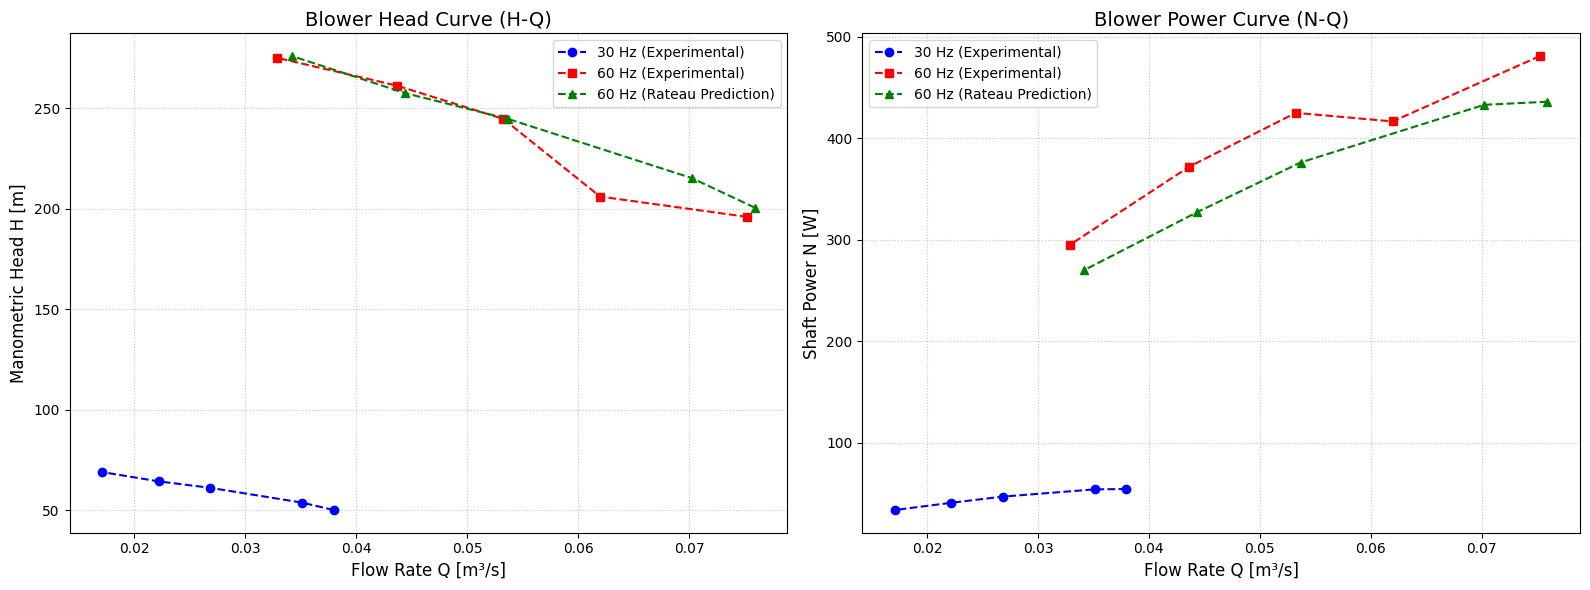

In [14]:
# Plotting H-Q and N-Q Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

datasets = [
    (freq_30_df, '30 Hz (Experimental)', 'blue', 'o'),
    (freq_60_df, '60 Hz (Experimental)', 'red', 's'),
    (freq_60_predicted, '60 Hz (Rateau Prediction)', 'green', '^')
]

for df, label, color, marker in datasets:
    q_vals = [x.nominal_value for x in df['Q (m³/s)']]
    h_vals = [x.nominal_value for x in df['H (m)']]
    n_vals = [x.nominal_value for x in df['N (W)']]
    
    # Head vs Flow Rate
    ax1.plot(q_vals, h_vals, label=label, color=color, marker=marker, linestyle='--')
    # Power vs Flow Rate
    ax2.plot(q_vals, n_vals, label=label, color=color, marker=marker, linestyle='--')

# Formatting ax1 (H-Q)
ax1.set_title('Blower Head Curve (H-Q)', fontsize=14)
ax1.set_xlabel('Flow Rate Q [m³/s]', fontsize=12)
ax1.set_ylabel('Manometric Head H [m]', fontsize=12)
ax1.grid(True, which='both', linestyle=':', alpha=0.7)
ax1.legend()

# Formatting ax2 (N-Q)
ax2.set_title('Blower Power Curve (N-Q)', fontsize=14)
ax2.set_xlabel('Flow Rate Q [m³/s]', fontsize=12)
ax2.set_ylabel('Shaft Power N [W]', fontsize=12)
ax2.grid(True, which='both', linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()